# 03 logistic regression

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_auc_score, roc_curve, auc)

import shap
import lime
import lime.lime_tabular
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, precision_recall_curve

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # unified 15-feature set
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_level"]  # string labels: low / medium / high


## train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # preserves class balance in both splits
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (400, 15)   test: (100, 15)


## pipeline + hyperparameter tuning

In [5]:
pipeline = Pipeline([  # scaler + model chained → no data leakage
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}  # C: inverse regularisation strength
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # stratified folds maintain class ratio

search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)  # exhaustive C sweep
search.fit(X_train, y_train)

best_model = search.best_estimator_  # pipeline with optimal C
print("best C:", search.best_params_)

best C: {'model__C': 10}


## regularisation path (C selection)

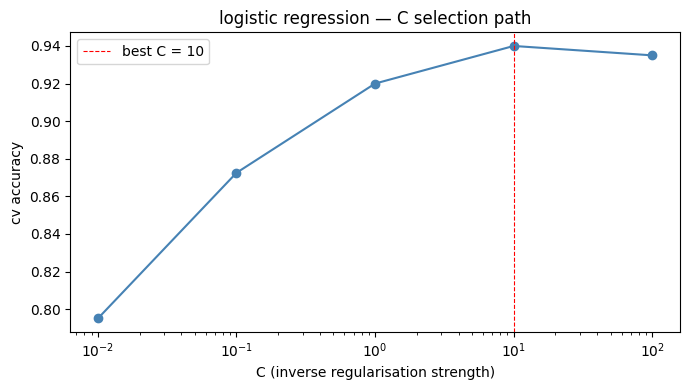

In [6]:
C_grid = param_grid["model__C"]
mean_scores = search.cv_results_["mean_test_score"]  # CV accuracy per C value

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(C_grid, mean_scores, "o-", color="steelblue")
ax.axvline(search.best_params_["model__C"], color="red", linestyle="--",
           linewidth=0.8, label=f"best C = {search.best_params_['model__C']}")  # selected C
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("cv accuracy")
ax.set_title("logistic regression — C selection path")
ax.legend()
plt.tight_layout()
plt.show()

## cross-validation scores

In [7]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")  # nested CV on training set only
print(f"cv accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cv accuracy: 0.9400 ± 0.0200


## overfitting check

In [8]:
best_model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_model.predict(X_train))  # in-sample accuracy
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))   # out-of-sample accuracy

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}")
print(f"train-test gap: {train_acc - test_acc:+.4f}")  # small gap, widened set is not overfitting

train accuracy: 0.9825
test  accuracy: 0.9500
train-test gap: +0.0325


Train 0.98 vs test 0.95, gap **+0.03** — basically no overfitting.

## final evaluation

In [9]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)  # class probabilities for ROC-AUC

print("accuracy  :", accuracy_score(y_test, y_pred))
print("weighted f1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred))  # per-class precision / recall / F1

accuracy  : 0.95
weighted f1: 0.9501492537313433

              precision    recall  f1-score   support

        high       0.97      0.94      0.96        34
         low       0.97      0.97      0.97        33
      medium       0.91      0.94      0.93        33

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



## confusion matrix

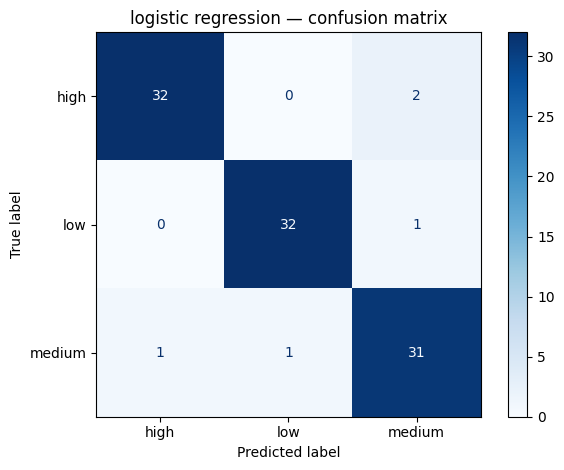

In [10]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(cmap="Blues")
plt.title("logistic regression — confusion matrix")
plt.tight_layout()
plt.show()

Most errors are between neighbouring classes (medium vs high), rarely low vs high.

## multiclass roc-auc

multiclass ROC-AUC (OvR): 0.9941


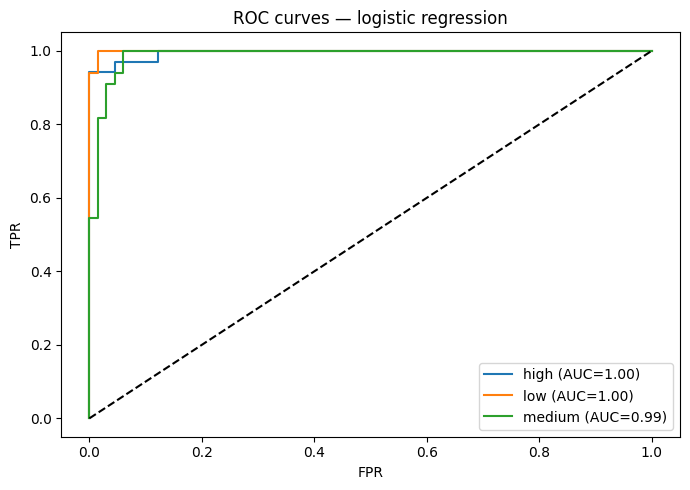

In [11]:
classes = best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)  # OvR binarisation for multiclass ROC

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")  # macro-average AUC
print("multiclass ROC-AUC (OvR):", round(roc_auc, 4))

fig, ax = plt.subplots(figsize=(7, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curves — logistic regression")
ax.legend()
plt.tight_layout()
plt.show()

All three classes have high AUC — clean separation.

## probability calibration

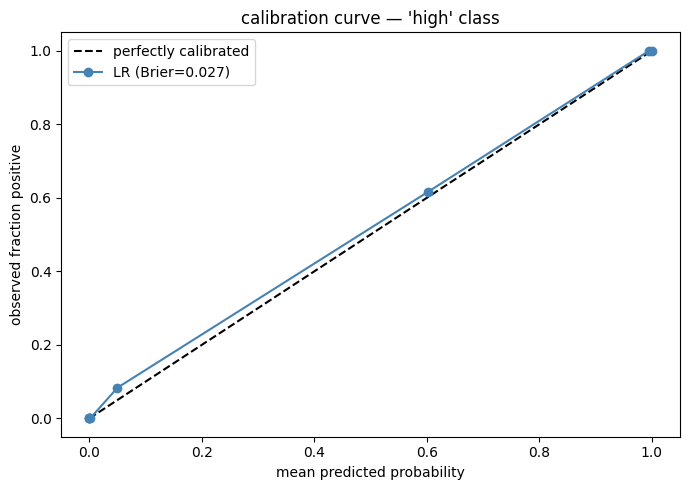

Brier score (high class): 0.0272  (0 = perfect, lower is better)


In [12]:
# one-vs-rest calibration for the "high" class
classes_list = list(best_model.classes_)
high_i = classes_list.index("high")
y_test_high = (y_test.values == "high").astype(int)         # 1 if truly high
prob_high   = best_model.predict_proba(X_test)[:, high_i]    # predicted P(high)

frac_pos, mean_pred = calibration_curve(y_test_high, prob_high, n_bins=8, strategy="quantile")
brier = brier_score_loss(y_test_high, prob_high)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.plot(mean_pred, frac_pos, "o-", color="steelblue", label=f"LR (Brier={brier:.3f})")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed fraction positive")
ax.set_title("calibration curve — 'high' class")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier score (high class): {brier:.4f}  (0 = perfect, lower is better)")

Brier **0.027** (near 0): the probabilities are reliable, so the deployment app can trust them as confidence scores.

## decision threshold analysis

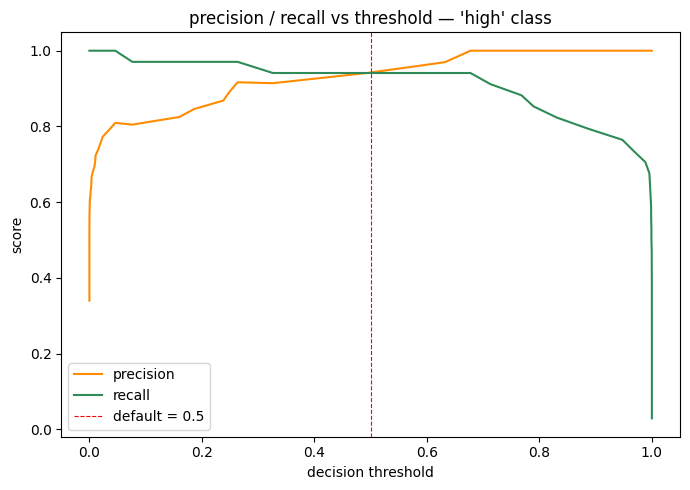

to reach recall >= 90%: threshold ~ 0.71 (precision 1.00)


In [13]:
prec, rec, thr = precision_recall_curve(y_test_high, prob_high)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thr, prec[:-1], label="precision", color="darkorange")
ax.plot(thr, rec[:-1],  label="recall",    color="seagreen")
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="default = 0.5")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("precision / recall vs threshold — 'high' class")
ax.legend()
plt.tight_layout()
plt.show()

# example: threshold that prioritises recall (catch >=90% of high emitters)
target_recall = 0.90
ok = rec[:-1] >= target_recall
if ok.any():
    t_idx = np.where(ok)[0][-1]
    print(f"to reach recall >= {target_recall:.0%}: threshold ~ {thr[t_idx]:.2f} "
          f"(precision {prec[t_idx]:.2f})")

Default cutoff 0.5 works well. To catch 90% of high emitters, drop the threshold to ~0.71 — useful if missing a high emitter is worse than a false alarm.

## coefficient interpretation

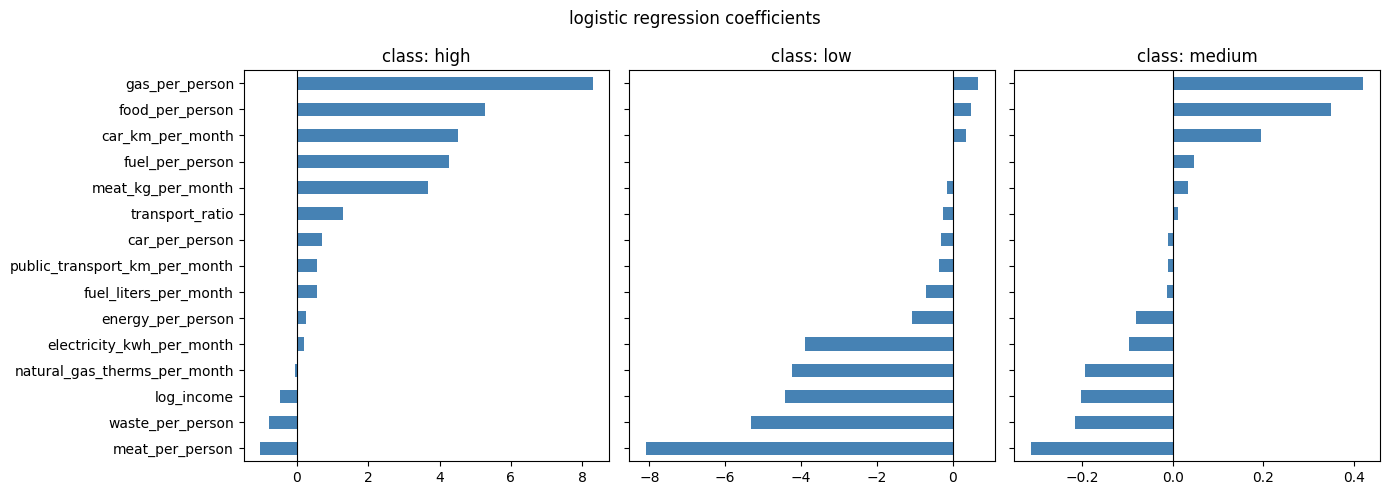

In [14]:
coef_df = pd.DataFrame(  # one coefficient column per class (OvR)
    best_model.named_steps["model"].coef_.T,
    index=feature_cols,
    columns=best_model.classes_
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, cls in zip(axes, best_model.classes_):
    coef_df[cls].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"class: {cls}")

plt.suptitle("logistic regression coefficients")
plt.tight_layout()
plt.show()

Consumption volumes push toward "high"; per-capita efficiency pushes toward "low".

## shap — linear explainer (global)

c:\Users\YJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


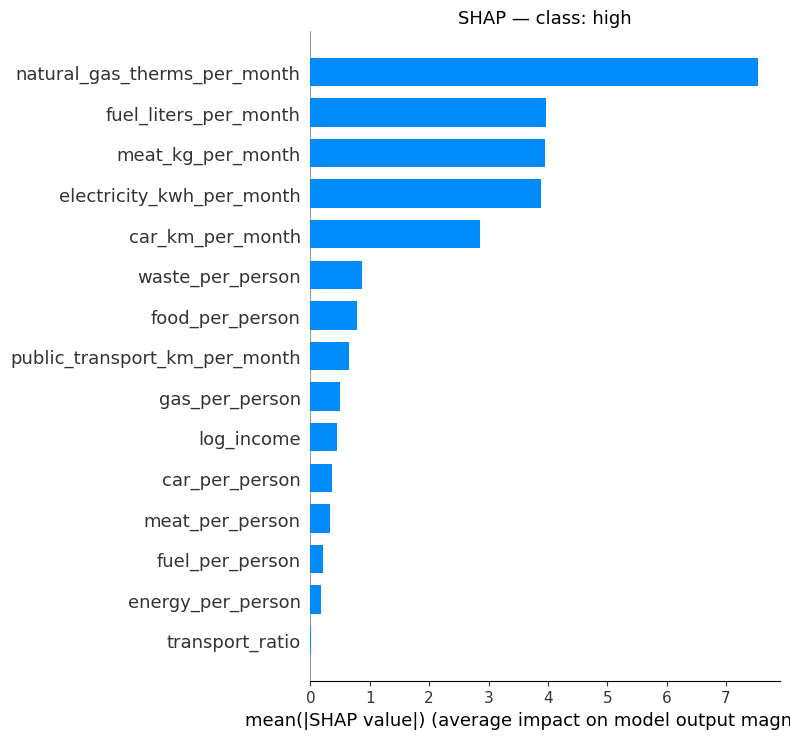

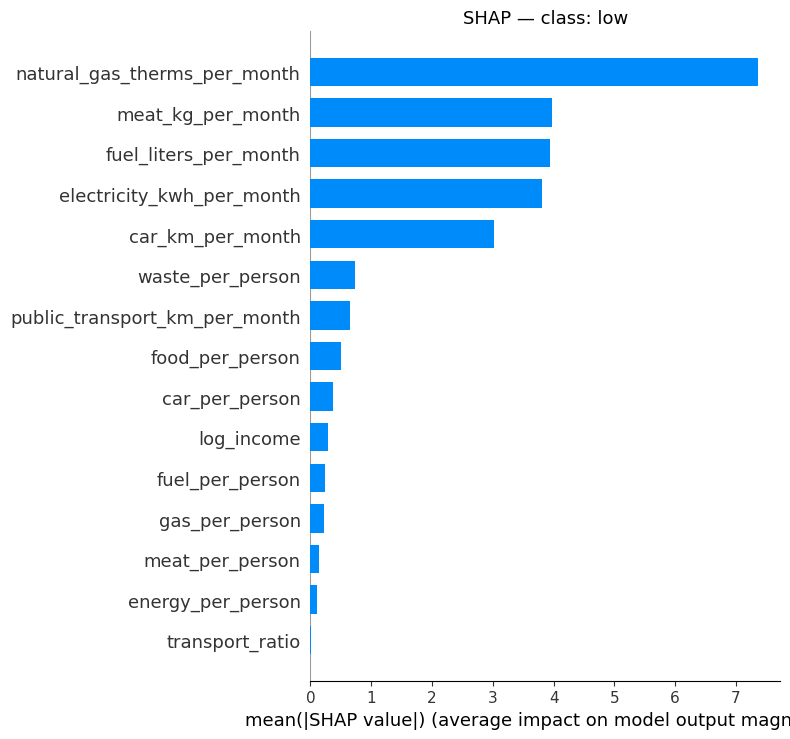

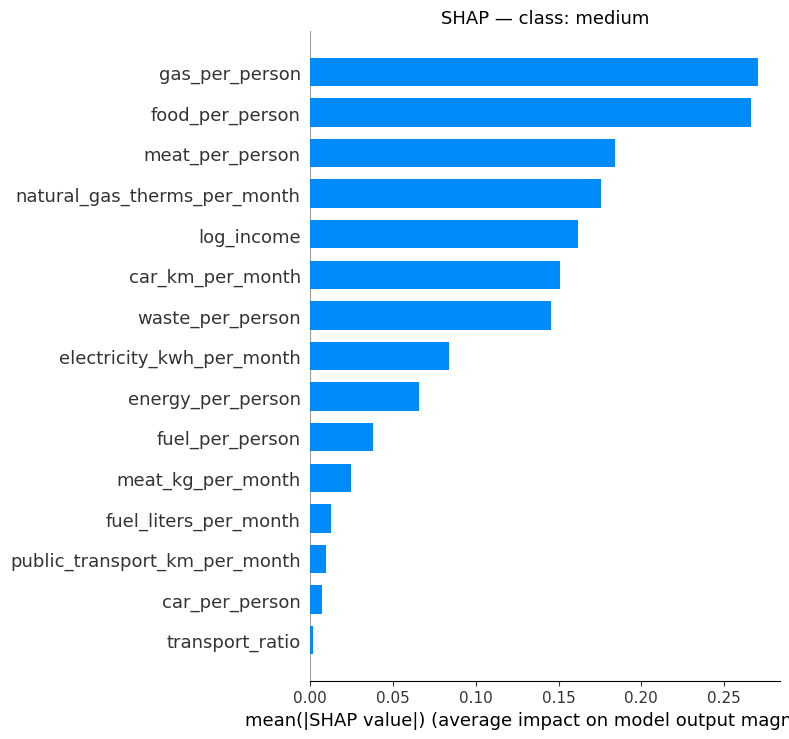

In [15]:
scaler = best_model.named_steps["scaler"]
lr     = best_model.named_steps["model"]

X_train_scaled = scaler.transform(X_train)  # manual scaling outside pipeline for SHAP
X_test_scaled  = scaler.transform(X_test)

explainer_shap  = shap.LinearExplainer(lr, X_train_scaled, feature_perturbation="interventional")  # interventional: marginalises feature correlations
shap_values_raw = explainer_shap.shap_values(X_test_scaled)

if not isinstance(shap_values_raw, list):
    shap_values_raw = [shap_values_raw]

n = len(feature_cols)
shap_values_all = [v[:, :n] for v in shap_values_raw]
shap_3d = np.array(shap_values_all[0])  # (n_samples, n_features, n_classes)
class_labels = list(best_model.classes_)

for i, cls in enumerate(class_labels):
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.sca(ax)
    shap.summary_plot(
        shap_3d[:, :, i],
        X_test_scaled[:, :n],
        feature_names=feature_cols,
        plot_type="bar", max_display=len(feature_cols), show=False
    )
    ax.set_title(f"SHAP — class: {cls}", fontsize=13)
    plt.tight_layout()
    plt.show()

## shap — beeswarm (high emission class)

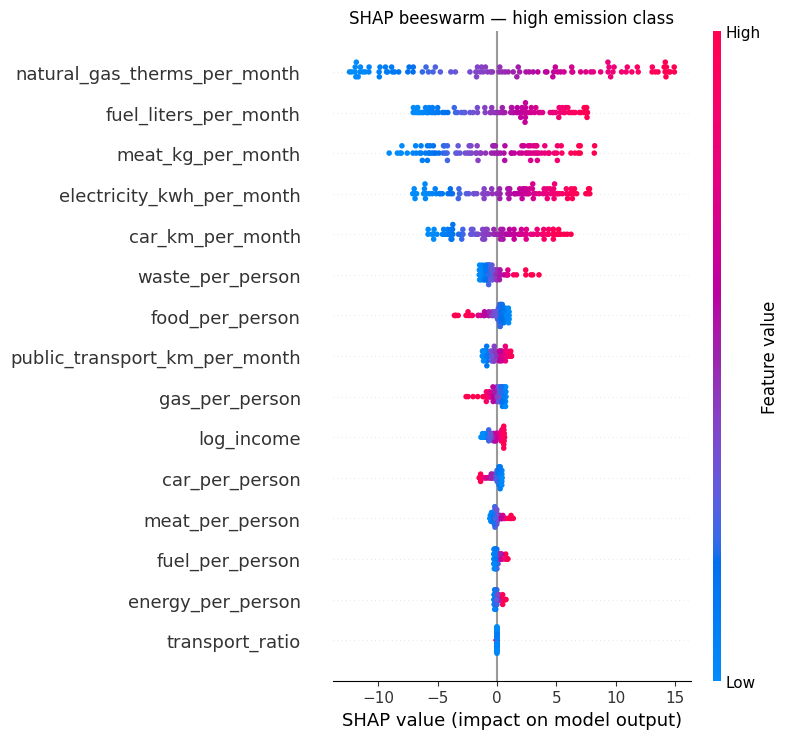

In [16]:
high_idx = class_labels.index("high")  # index into class dimension of shap_3d

shap.summary_plot(
    shap_3d[:, :, high_idx],
    X_test_scaled[:, :n],
    feature_names=feature_cols,
    max_display=len(feature_cols), show=False
)
plt.title("SHAP beeswarm — high emission class")
plt.tight_layout()
plt.show()

## shap — waterfall (single prediction)

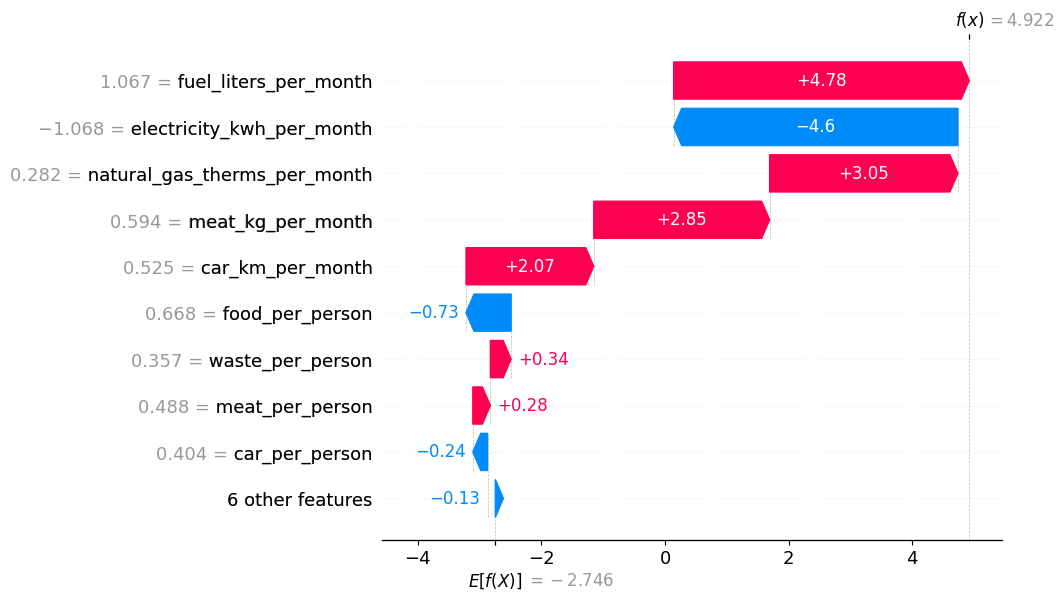

In [17]:
pred_labels = best_model.predict(X_test)
pick = (pred_labels == "high").nonzero()[0][0]  # first predicted "high" sample

ev = explainer_shap.expected_value
base_val = ev[high_idx] if hasattr(ev, "__len__") else ev  # handle scalar vs array expected_value

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_3d[pick, :, high_idx],
        base_values  = base_val,
        data         = X_test_scaled[pick, :n],
        feature_names=feature_cols
    )
)

## lime — local instance explanation

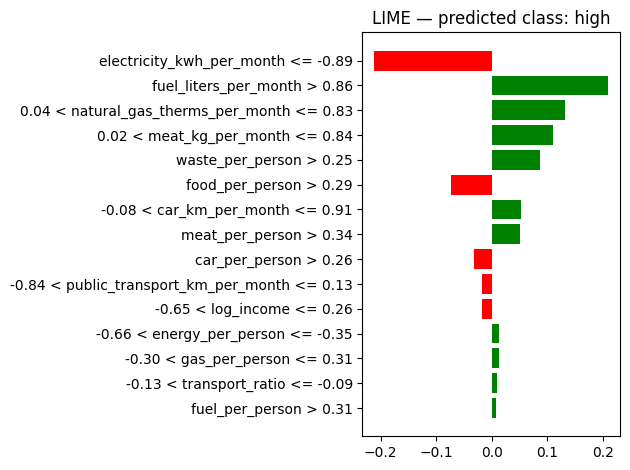

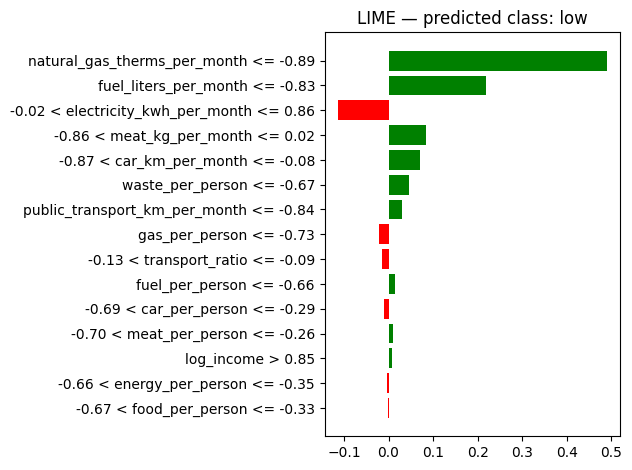

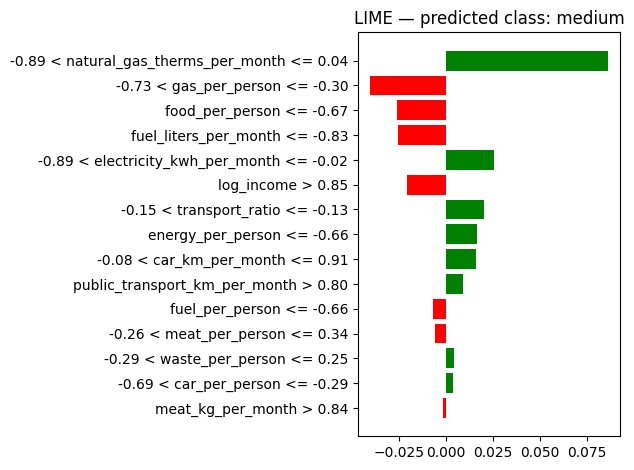

In [18]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_cols,
    class_names=class_labels,
    discretize_continuous=True,  # LIME bins continuous features for local linear fit
    random_state=42
)

for cls in class_labels:
    idx = (pred_labels == cls).nonzero()[0][0]
    exp = explainer_lime.explain_instance(  # perturbs one sample; fits local linear model
        X_test_scaled[idx],
        lr.predict_proba,
        num_features=len(feature_cols),
        labels=list(range(len(class_labels)))
    )
    cls_idx = class_labels.index(cls)
    exp.as_pyplot_figure(label=cls_idx)
    plt.title(f"LIME — predicted class: {cls}")
    plt.tight_layout()
    plt.show()

## save model for deployment

In [19]:
import joblib

# save the trained LR pipeline (scaler + model) + feature list for deployment
joblib.dump(best_model, MODELS_DIR / "model_lr.pkl")          # full pipeline: handles scaling internally
joblib.dump(feature_cols, MODELS_DIR / "features_lr.pkl")     # feature order required at inference
print("saved: model_lr.pkl, features_lr.pkl")


saved: model_lr.pkl, features_lr.pkl
